# Loni: red-edge crop stress, read through phenology

NDVI saturates once the canopy closes (sugarcane, banana, dense Kharif crops), so a crop can lose chlorophyll while its NDVI hardly changes.
The Sentinel-2 red-edge bands (B05 705 nm, B06 740 nm, B07 783 nm) respond to leaf chlorophyll, not just canopy cover.
This notebook looks for **red-edge / NDVI decoupling**: times when a field's red-edge signal is lower than its canopy greenness implies.
It then uses each field's own season to separate **stress** (decoupling before or at the NDVI peak) from **normal senescence** (decoupling after the peak, when chlorophyll is expected to break down).

**Indices** (reflectance = DN × 0.0001 − 0.1)

| index | formula | why |
|---|---|---|
| NDVI | (B08 − B04)/(B08 + B04) | canopy greenness (saturates) |
| NDRE | (B8A − B05)/(B8A + B05) | chlorophyll, less saturation |
| CIre | B07/B05 − 1 | red-edge chlorophyll index (Gitelson), close to linear in canopy chlorophyll |
| S2REP | 705 + 35·((B04+B07)/2 − B05)/(B06 − B05) | red-edge position (nm); shifts to shorter wavelengths under stress |

**Data access:** reads the public `sentinel-cogs` bucket (Element84 Earth Search L2A COGs, tile 43QDA) directly with windowed COG reads, using the STAC item JSON in each scene folder for cloud cover and scale/offset.
It needs no STAC API and no account, and works in Colab or locally.

**Pipeline:** cadastral fields + SAM segments → segments nested in fields → scene list → SCL cloud mask → 10 m indices → per-segment and per-field zonal stats → despike → 5-day gap-fill + Savitzky–Golay → NDRE-vs-NDVI expectation → decoupling z → phenology per season → stress flags, maps, animation.

In [1]:
import importlib, subprocess, sys
for pkg in ["geopandas", "rasterio", "scipy", "matplotlib", "PIL"]:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", {"PIL": "pillow"}.get(pkg, pkg)], check=True)

## 1. Settings

In [2]:
import os, re, json, warnings, datetime as dt
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import numpy as np, pandas as pd, geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_origin
from rasterio.windows import from_bounds
from scipy.ndimage import binary_dilation
from scipy.signal import savgol_filter
import requests
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
warnings.filterwarnings("ignore", category=RuntimeWarning)

START, END = "2025-06-01", "2026-09-20"   # Kharif 2025 -> Rabi 2025-26 -> summer 2026 -> Kharif 2026 (to date)
TILE = ("43", "Q", "DA")                  # MGRS tile covering Loni
MAX_TILE_CLOUD = 80                       # skip scenes whose whole-tile cloud cover is above this (%)
MIN_FIELD_VALID = 0.5                     # keep a field-date only if >= 50 % of its pixels are clear
EPSG = 32643
BUCKET = "https://sentinel-cogs.s3.us-west-2.amazonaws.com"
RAW = "https://raw.githubusercontent.com/somdeepkundu/Bhumi-Buddhimatta/main/aps2/"
OUT = Path("rededge_stress_outputs"); OUT.mkdir(exist_ok=True)

# Kharif / Rabi / summer windows used for phenology metrics
SEASONS = {
    "Kharif 2025": ("2025-06-01", "2025-10-31"),
    "Rabi 2025-26": ("2025-11-01", "2026-03-15"),
    "Summer 2026": ("2026-03-16", "2026-05-31"),
    "Kharif 2026": ("2026-06-01", END),
}
os.environ.setdefault("GDAL_DISABLE_READDIR_ON_OPEN", "EMPTY_DIR")
os.environ.setdefault("GDAL_HTTP_MAX_RETRY", "4")
os.environ.setdefault("GDAL_HTTP_RETRY_DELAY", "2")

'2'

## 2. Cadastral fields and SAM segments, with each segment nested in its best-overlap field

In [3]:
def load(name):
    for p in (Path(name), Path("aps2") / name):
        if p.exists():
            return gpd.read_file(p)
    return gpd.read_file(RAW + name)

fields = load("withSurveyNo_fieldsOnly_wgs84.geojson").to_crs(EPSG).reset_index(drop=True)
fields["field_id"] = [f"FLD{i:04d}" for i in range(len(fields))]
fields["field_area_ha"] = fields.geometry.area / 1e4

segs = load("segmentation_results.gpkg").to_crs(EPSG).reset_index(drop=True)
segs["seg_id"] = np.arange(len(segs))

inter = gpd.overlay(segs[["seg_id", "geometry"]], fields[["field_id", "geometry"]], how="intersection", keep_geom_type=True)
inter["ov"] = inter.geometry.area
best = inter.sort_values("ov").drop_duplicates("seg_id", keep="last")[["seg_id", "field_id"]]
segs = segs.merge(best, on="seg_id", how="left")
print(f"{len(fields)} fields, {len(segs)} SAM segments; {segs.field_id.notna().sum()} nested in a field, "
      f"{segs.field_id.isna().sum()} outside any field (roads / built-up)")
segs = segs[segs.field_id.notna()].reset_index(drop=True)

469 fields, 7604 SAM segments; 6799 nested in a field, 805 outside any field (roads / built-up)


## 3. 10 m analysis grid (snapped to the 20 m Sentinel-2 grid) and label rasters

In [4]:
x0, y0, x1, y1 = pd.concat([fields.geometry, segs.geometry]).total_bounds
x0, y1 = np.floor((x0 - 60 - 399960) / 20) * 20 + 399960, np.ceil((y1 + 60 - 2100000) / 20) * 20 + 2100000
x1, y0 = np.ceil((x1 + 60 - 399960) / 20) * 20 + 399960, np.floor((y0 - 60 - 2100000) / 20) * 20 + 2100000
BOUNDS = (x0, y0, x1, y1)
H, W = int((y1 - y0) / 10), int((x1 - x0) / 10)
TRANSFORM = from_origin(x0, y1, 10, 10)
seg_lbl = rasterize(zip(segs.geometry, segs.index + 1), out_shape=(H, W), transform=TRANSFORM, fill=0, dtype="int32")
NSEG = len(segs) + 1
seg_npix = np.bincount(seg_lbl.ravel(), minlength=NSEG)
seg_field = np.r_[[-1], pd.Categorical(segs.field_id, categories=fields.field_id).codes]  # label -> field row
print(f"grid {W} x {H} px @10 m; {(seg_npix[1:] > 0).sum()} segments cover >= 1 pixel")

grid 456 x 604 px @10 m; 6632 segments cover >= 1 pixel


## 4. Scene list from the public COG bucket (no STAC API needed)

In [5]:
S = requests.Session()
def list_prefix(prefix):
    r = S.get(BUCKET, params={"list-type": "2", "prefix": prefix, "delimiter": "/"}, timeout=60); r.raise_for_status()
    return re.findall(r"<Prefix>([^<]+)</Prefix>", r.text)[1:]

months = pd.period_range(START, END, freq="M")
scene_dirs = []
with ThreadPoolExecutor(8) as ex:
    for lst in ex.map(lambda m: list_prefix(f"sentinel-s2-l2a-cogs/{'/'.join(TILE)}/{m.year}/{m.month}/"), months):
        scene_dirs += lst

def item(d):
    sid = d.rstrip("/").split("/")[-1]
    for attempt in range(4):
        try:
            j = S.get(f"{BUCKET}/{d}{sid}.json", timeout=60).json(); break
        except Exception:
            j = None
    if j is None:  # folder without a usable item JSON (partial upload) -> skip
        print("skipping", sid); return None
    return dict(id=sid, date=pd.Timestamp(j["properties"]["datetime"][:10]), cloud=j["properties"].get("eo:cloud_cover", 100),
                assets={k: (a["href"], a.get("raster:bands", [{}])[0].get("scale", 1e-4), a.get("raster:bands", [{}])[0].get("offset", 0.0))
                        for k, a in j["assets"].items()})

with ThreadPoolExecutor(8) as ex:
    items = pd.DataFrame([i for i in ex.map(item, scene_dirs) if i])
items = items[(items.date >= START) & (items.date <= END)]
# same-day reprocessings (_0/_1): keep the latest processing
items = items.sort_values("id").drop_duplicates("date", keep="last")
print(f"{len(items)} unique acquisition dates; {(items.cloud <= MAX_TILE_CLOUD).sum()} under {MAX_TILE_CLOUD}% tile cloud")
items = items[items.cloud <= MAX_TILE_CLOUD].sort_values("date").reset_index(drop=True)

skipping S2A_43QDA_20260624_0_L2A


115 unique acquisition dates; 77 under 80% tile cloud


## 5. Read bands, mask clouds, compute indices, zonal stats

The 20 m bands (B05, B06, B07, B8A, SCL) are upsampled to 10 m by pixel replication. The grid is snapped to the 20 m raster, so no resampling is needed.
Clear pixels are SCL 4 (vegetation) and 5 (bare soil). Cloud, cirrus and shadow (SCL 3, 8, 9, 10) are dilated by 40 m.
Every ratio has a denominator guard. That guard is the fix for the earlier NDVI blow-ups (values up to 85,149 where NIR + red ≈ 0).

In [6]:
BANDS10 = {"red": "red", "nir": "nir"}
BANDS20 = {"re1": "rededge1", "re2": "rededge2", "re3": "rededge3", "n8a": "nir08", "scl": "scl"}
IDX = ["ndvi", "ndre", "cire", "s2rep"]

def read(href, res):
    with rasterio.open(href) as src:
        w = from_bounds(*BOUNDS, transform=src.transform)
        a = src.read(1, window=w.round_offsets().round_lengths(), out_dtype="float32")
    return a if res == 10 else np.kron(a, np.ones((2, 2), "float32"))

def scene_indices(row):
    A = row.assets
    b = {k: read(A[a][0], 10) * A[a][1] + A[a][2] for k, a in BANDS10.items()}
    for k, a in BANDS20.items():
        v = read(A[a][0], 20)
        b[k] = v if k == "scl" else v * A[a][1] + A[a][2]
    scl = b["scl"].astype("uint8")
    cloud20 = np.isin(scl[::2, ::2], [3, 8, 9, 10])
    cloud = np.kron(binary_dilation(cloud20, iterations=2), np.ones((2, 2), bool))
    ok = np.isin(scl, [4, 5]) & ~cloud
    for k in ["red", "nir", "re1", "re2", "re3", "n8a"]:
        ok &= b[k] > 0
    r, n, e1, e2, e3, n8 = (b[k] for k in ["red", "nir", "re1", "re2", "re3", "n8a"])
    with np.errstate(all="ignore"):
        out = {
            "ndvi": np.where((n + r) > 0.01, (n - r) / (n + r), np.nan),
            "ndre": np.where((n8 + e1) > 0.01, (n8 - e1) / (n8 + e1), np.nan),
            "cire": np.where(e1 > 0.01, e3 / e1 - 1, np.nan),
            "s2rep": np.where((e2 - e1) > 0.005, 705 + 35 * ((r + e3) / 2 - e1) / (e2 - e1), np.nan),
        }
    out["ndvi"] = np.clip(out["ndvi"], -1, 1); out["ndre"] = np.clip(out["ndre"], -1, 1)
    out["cire"] = np.where((out["cire"] > -1) & (out["cire"] < 20), out["cire"], np.nan)
    out["s2rep"] = np.where((out["s2rep"] > 690) & (out["s2rep"] < 760), out["s2rep"], np.nan)
    good = ok & np.all([np.isfinite(v) for v in out.values()], axis=0)
    lbl = np.where(good, seg_lbl, 0).ravel()
    res = {"n": np.bincount(lbl, minlength=NSEG)}
    for k, v in out.items():
        res[k] = np.bincount(lbl, weights=np.nan_to_num(v).ravel(), minlength=NSEG)
    return row.date, res

F = len(fields)
CACHE = (OUT / "field_rededge_raw.csv").exists() and (OUT / "segment_rededge_raw.csv.gz").exists()
if CACHE:  # delete the two raw CSVs in OUT to force a fresh pull
    print("using cached pull from", OUT)
    fld_raw = pd.read_csv(OUT / "field_rededge_raw.csv", parse_dates=["date"])
    seg_raw = pd.read_csv(OUT / "segment_rededge_raw.csv.gz", parse_dates=["date"])
seg_rows, fld_rows = [], []
fld_npix = np.bincount(seg_field[1:] + 0, weights=seg_npix[1:], minlength=F)
with ThreadPoolExecutor(8) as ex:
    for i, (date, r) in enumerate(ex.map(scene_indices, [] if CACHE else items.itertuples())):
        n = r["n"]
        m = (n[1:] >= 2) & (n[1:] >= 0.5 * seg_npix[1:])
        seg_rows.append(pd.DataFrame({"seg_id": segs.seg_id.values[m], "field_id": segs.field_id.values[m], "date": date,
                                      "valid_frac": (n[1:] / np.maximum(seg_npix[1:], 1))[m],
                                      **{k: (r[k][1:] / np.maximum(n[1:], 1))[m] for k in IDX}}))
        fn = np.bincount(seg_field[1:], weights=n[1:], minlength=F)
        fs = {k: np.bincount(seg_field[1:], weights=r[k][1:], minlength=F) for k in IDX}
        fm = (fn >= MIN_FIELD_VALID * fld_npix) & (fn >= 4)
        fld_rows.append(pd.DataFrame({"field_id": fields.field_id.values[fm], "date": date, "valid_frac": (fn / np.maximum(fld_npix, 1))[fm],
                                      **{k: (fs[k] / np.maximum(fn, 1))[fm] for k in IDX}}))
        if i % 10 == 0:
            print(f"{i+1}/{len(items)} {date.date()}  fields clear: {fm.sum()}")

if not CACHE:
  seg_raw = pd.concat(seg_rows, ignore_index=True)
  fld_raw = pd.concat(fld_rows, ignore_index=True)
  # intra-field spread of NDRE across SAM segments (same idea as the NDVI CV analysis)
  spread = seg_raw.groupby(["field_id", "date"]).agg(ndre_seg_std=("ndre", "std"), n_segments=("seg_id", "size")).reset_index()
  fld_raw = fld_raw.merge(spread, on=["field_id", "date"], how="left")
  seg_raw.to_csv(OUT / "segment_rededge_raw.csv.gz", index=False, float_format="%.4f")
  fld_raw.to_csv(OUT / "field_rededge_raw.csv", index=False, float_format="%.4f")
print(f"\n{fld_raw.date.nunique()} dates with >= 1 clear field; {len(fld_raw)} field-date and {len(seg_raw)} segment-date observations")
print(fld_raw[IDX].describe().round(3))

using cached pull from rededge_stress_outputs



69 dates with >= 1 clear field; 6846 field-date and 106987 segment-date observations
           ndvi      ndre      cire     s2rep
count  6846.000  6846.000  6846.000  6846.000
mean      0.602     0.384     1.142   717.170
std       0.152     0.092     0.472     4.097
min       0.054     0.085     0.168   698.128
25%       0.507     0.326     0.803   714.687
50%       0.614     0.391     1.102   717.101
75%       0.713     0.449     1.419   719.488
max       0.974     0.654     3.544   747.217


## 6. Despike, gap-fill onto a 5-day grid, Savitzky–Golay smoothing

Missed haze or cloud edges pull every index down together.
A field-date is dropped when its NDVI is more than 0.12 below the rolling median of its neighbours (and more than 3 MAD away).
Gaps of up to 40 days are interpolated. Longer gaps (the monsoon) are left empty, not invented.

In [7]:
def spike(nd):
    med = nd.rolling(5, center=True, min_periods=3).median()
    dev = nd - med
    mad = dev.abs().rolling(9, center=True, min_periods=3).median() * 1.4826
    return (dev < -0.12) & (dev.abs() > 3 * mad.clip(lower=0.02))

n0 = len(fld_raw)
fld_raw = fld_raw.sort_values(["field_id", "date"]).reset_index(drop=True)
fld_clean = fld_raw[~fld_raw.groupby("field_id").ndvi.transform(spike).astype(bool)].copy()
print(f"despike removed {n0 - len(fld_clean)} of {n0} field-dates ({100*(n0-len(fld_clean))/n0:.1f}%)")

GRID = pd.date_range(START, END, freq="5D")
MAX_DAYS_FROM_OBS = 20  # blank grid points > 20 d from any real obs, i.e. gaps > ~40 d stay empty

def smooth(g):
    s = g.set_index("date")[IDX].groupby(level=0).mean()
    obs = pd.Series(1, index=s.index).reindex(s.index.union(GRID)).fillna(0)
    s = s.reindex(s.index.union(GRID))
    # distance (days) to nearest real observation, to blank long gaps
    t = s.index.values.astype("datetime64[D]").astype(int)
    real = t[obs.values == 1]
    near = np.abs(t[:, None] - real[None, :]).min(1) if len(real) else np.full(len(t), 999)
    s = s.interpolate("time", limit_area="inside").loc[GRID]
    gapmask = pd.Series(near, index=obs.index).loc[GRID].values
    out = pd.DataFrame(index=GRID)
    for k in IDX:
        v = s[k].values.copy()
        fin = np.isfinite(v)
        if fin.sum() >= 7:
            sm = v.copy()
            # smooth each contiguous finite run separately
            idx = np.flatnonzero(fin); runs = np.split(idx, np.flatnonzero(np.diff(idx) > 1) + 1)
            for rr in runs:
                if len(rr) >= 7:
                    sm[rr] = savgol_filter(v[rr], 7, 2)
            v = sm
        v[gapmask > MAX_DAYS_FROM_OBS] = np.nan  # inside a long (monsoon) gap
        out[k] = v
    out["ndvi"] = out.ndvi.clip(-1, 1); out["ndre"] = out.ndre.clip(-1, 1)
    return out.rename_axis("date").reset_index()

fld_sm = pd.concat([smooth(g).assign(field_id=fid) for fid, g in fld_clean.groupby("field_id")], ignore_index=True)
fld_sm.to_csv(OUT / "field_rededge_smoothed.csv", index=False, float_format="%.4f")
print(f"smoothed: {fld_sm.field_id.nunique()} fields x {len(GRID)} dates; ranges:")
print(fld_sm[IDX].agg(["min", "median", "max"]).round(3))

despike removed 87 of 6846 field-dates (1.3%)


smoothed: 407 fields x 96 dates; ranges:
         ndvi   ndre   cire    s2rep
min     0.096  0.089  0.172  699.325
median  0.668  0.419  1.269  717.278
max     0.965  0.655  3.508  739.481


## 7. Expected red-edge for a given greenness → decoupling z

1. **Village expectation.** All clear field-dates with NDVI ≥ 0.3 are binned by NDVI in steps of 0.02. The median NDRE in each bin is the NDRE that canopy greenness normally goes with in Loni.
2. **Residual z.** (NDRE − expected) / (robust spread in that bin).
3. **Decoupling z.** The residual z minus the field's own median residual z. This removes a steady offset from crop type (e.g. sugarcane sitting slightly above the village curve) and leaves only *changes* within the field.

A value of −1.5 or below means that on this date the field has clearly less chlorophyll than its greenness implies, compared with its own normal.

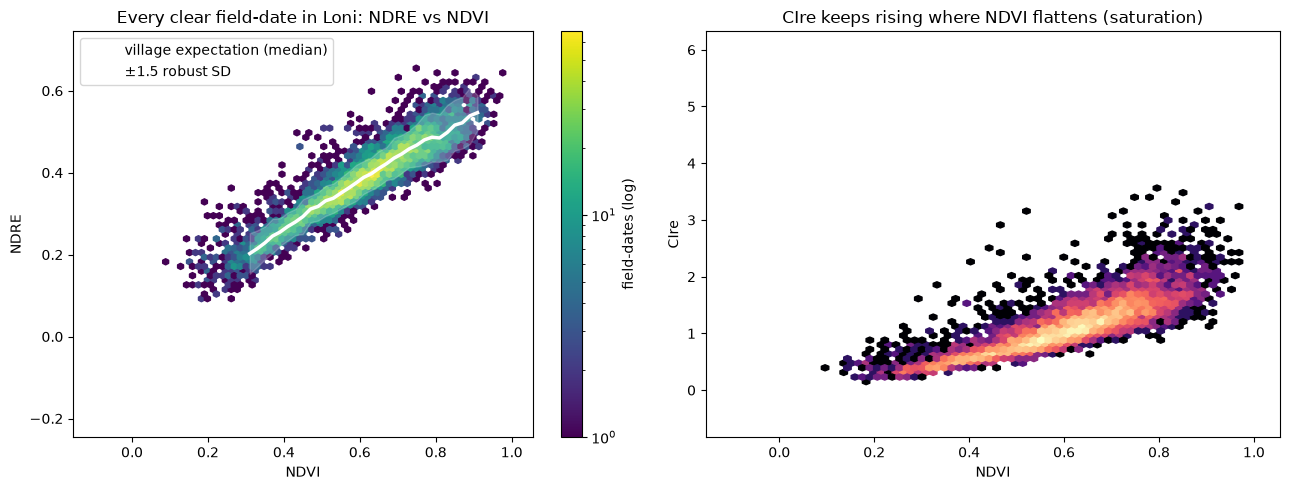

In [8]:
cal = fld_clean[fld_clean.ndvi >= 0.3].copy()
bins = np.arange(0.3, 0.96, 0.02)
cal["b"] = pd.cut(cal.ndvi, bins, labels=bins[:-1] + 0.01)
curve = cal.groupby("b", observed=True).ndre.agg(med="median", mad=lambda x: 1.4826 * np.median(np.abs(x - np.median(x))), n="size")
curve = curve[curve.n >= 20]
xc = curve.index.astype(float).values
exp_ndre = lambda ndvi: np.interp(ndvi, xc, curve.med.values)
spr_ndre = lambda ndvi: np.interp(ndvi, xc, curve.mad.clip(lower=0.01).values)

for df in (fld_clean, fld_sm):
    df["ndre_exp"] = exp_ndre(df.ndvi)
    df["resid_z"] = np.where(df.ndvi >= 0.3, (df.ndre - df.ndre_exp) / spr_ndre(df.ndvi), np.nan)
base = fld_clean.groupby("field_id").resid_z.median().rename("base_z")
for df in (fld_clean, fld_sm):
    df["decouple_z"] = df.resid_z - df.field_id.map(base)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
hb = ax[0].hexbin(fld_clean.ndvi, fld_clean.ndre, gridsize=70, bins="log", cmap="viridis", mincnt=1, extent=(-0.1, 1, -0.2, 0.7))
ax[0].plot(xc, curve.med, "w-", lw=2.5, label="village expectation (median)")
ax[0].fill_between(xc, curve.med - 1.5 * curve.mad, curve.med + 1.5 * curve.mad, color="w", alpha=0.2, label="±1.5 robust SD")
ax[0].set(xlabel="NDVI", ylabel="NDRE", title="Every clear field-date in Loni: NDRE vs NDVI"); ax[0].legend(loc="upper left")
plt.colorbar(hb, ax=ax[0], label="field-dates (log)")
ax[1].hexbin(fld_clean.ndvi, fld_clean.cire, gridsize=70, bins="log", cmap="magma", mincnt=1, extent=(-0.1, 1, -0.5, 6))
ax[1].set(xlabel="NDVI", ylabel="CIre", title="CIre keeps rising where NDVI flattens (saturation)")
plt.tight_layout(); plt.savefig(OUT / "01_ndre_vs_ndvi_expectation.png", dpi=150); plt.show()

## 8. Village-level seasonal signal

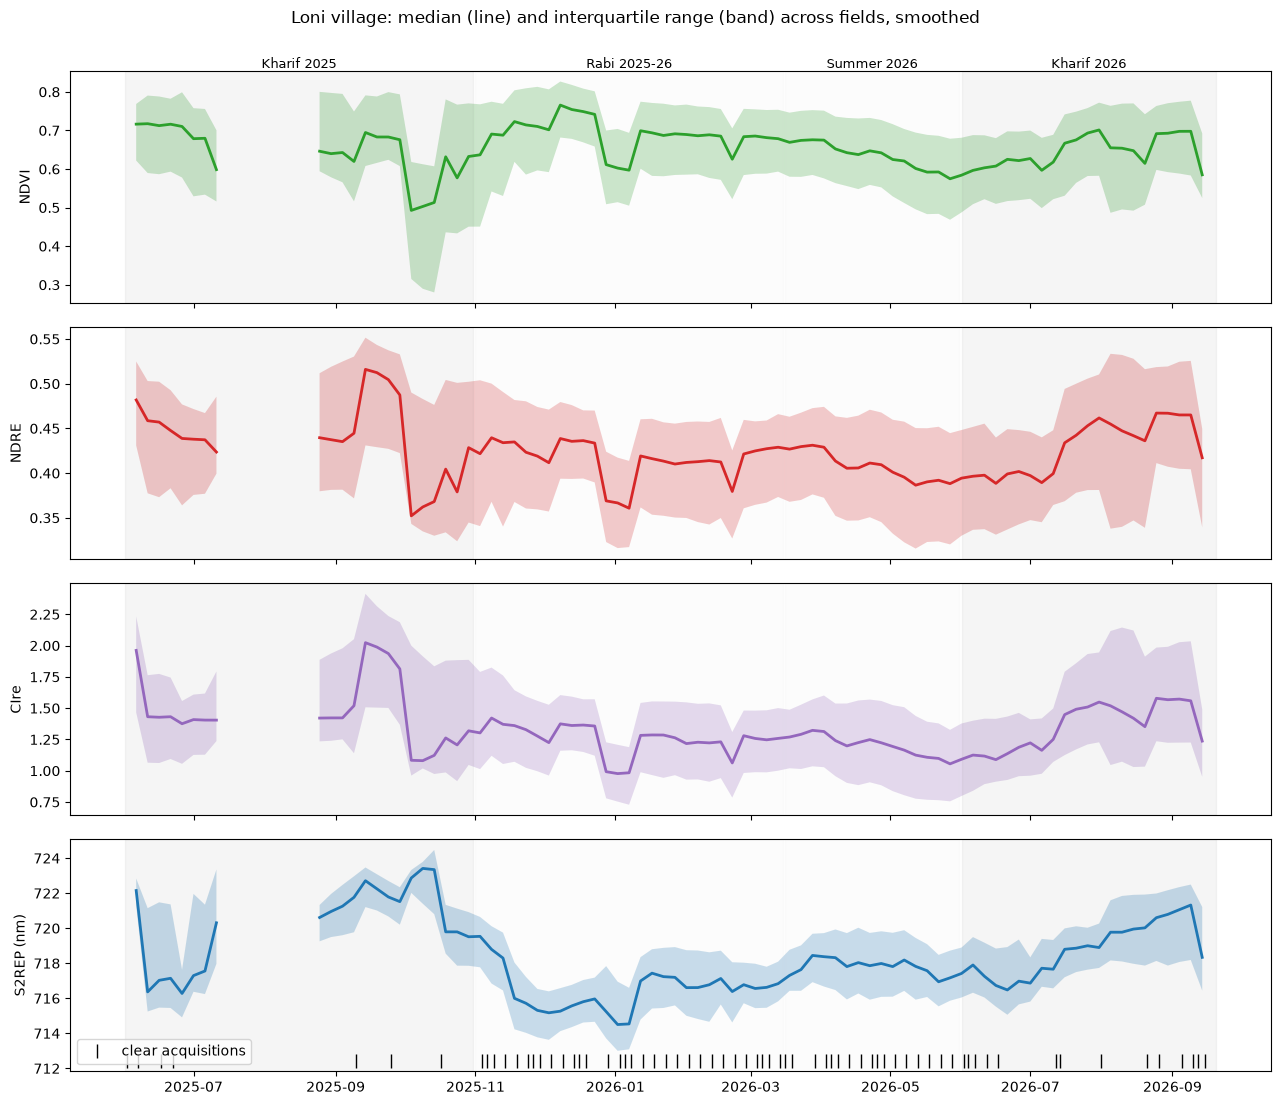

In [9]:
v = fld_sm.groupby("date")[IDX + ["decouple_z"]].quantile([0.25, 0.5, 0.75]).unstack()
fig, axs = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
spec = [("ndvi", "NDVI", "tab:green"), ("ndre", "NDRE", "tab:red"), ("cire", "CIre", "tab:purple"), ("s2rep", "S2REP (nm)", "tab:blue")]
for a, (k, lab, c) in zip(axs, spec):
    a.fill_between(v.index, v[(k, 0.25)], v[(k, 0.75)], color=c, alpha=0.25, lw=0)
    a.plot(v.index, v[(k, 0.5)], color=c, lw=2); a.set_ylabel(lab)
    for nm, (s0, s1) in SEASONS.items():
        a.axvspan(pd.Timestamp(s0), pd.Timestamp(s1), color="0.5" if "Kharif" in nm else "0.85", alpha=0.08)
for nm, (s0, s1) in SEASONS.items():
    axs[0].text(pd.Timestamp(s0) + (pd.Timestamp(s1) - pd.Timestamp(s0)) / 2, axs[0].get_ylim()[1], nm, ha="center", va="bottom", fontsize=9)
obs = fld_raw.groupby("date").size()
axs[-1].plot(obs.index, [axs[-1].get_ylim()[0]] * len(obs), "k|", ms=10, label="clear acquisitions")
axs[-1].legend(loc="lower left")
fig.suptitle("Loni village: median (line) and interquartile range (band) across fields, smoothed", y=1.0)
plt.tight_layout(); plt.savefig(OUT / "02_village_index_timeseries.png", dpi=150, bbox_inches="tight"); plt.show()

## 9. Phenology per field and season, and stress flags

For each field and season (only fields with a real crop: NDVI peak ≥ 0.45 and amplitude ≥ 0.15), the notebook computes:

* **POS_NDVI / POS_NDRE**: dates of the NDVI and NDRE peaks. **NDRE lead** = POS_NDVI − POS_NDRE in days. A clearly positive lead means chlorophyll started falling while the canopy was still green or still growing, i.e. premature chlorophyll loss.
* **Stress days before or at the peak**: days with decoupling z ≤ −1.5 between green-up (SOS) and POS_NDVI + 10 d. These count as stress.
* **Senescence days**: the same condition after the peak. This is expected crop ageing and is reported but **not** counted as stress.
* **Peak S2REP z**: the red-edge position at the peak compared with all cropped fields that season. A lower REP (blue shift) goes with lower chlorophyll.

| flag | rule |
|---|---|
| `f_decouple` | ≥ 15 stress days before or at the peak |
| `f_lead` | NDRE lead ≥ 20 days |
| `f_rep` | peak S2REP z ≤ −1 |

stress class = number of flags: 0 none, 1 mild, 2 moderate, 3 severe.

In [10]:
STEP = 5
def pheno(g, season, s0, s1):
    g = g[(g.date >= s0) & (g.date <= s1)].dropna(subset=["ndvi"])
    if len(g) < 6:
        return None
    nd = g.ndvi.values; mx, mn = nd.max(), nd.min()
    if mx < 0.45 or mx - mn < 0.15:
        return dict(season=season, cropped=False, ndvi_max=mx)
    ipk = int(np.argmax(nd)); pos = g.date.iloc[ipk]
    pre = g.iloc[: ipk + 1]; thr = mn + 0.5 * (mx - mn)
    sos = pre.date[pre.ndvi >= thr].min() if (pre.ndvi >= thr).any() else g.date.iloc[0]
    post = g.iloc[ipk:]; below = post.date[post.ndvi < thr]
    eos = below.min() if len(below) else pd.NaT
    gr = g.dropna(subset=["ndre"])
    pos_re = gr.date.iloc[int(np.argmax(gr.ndre.values))] if len(gr) else pd.NaT
    stressed = g.decouple_z <= -1.5
    in_pre = (g.date >= sos) & (g.date <= pos + pd.Timedelta(days=10))
    worst = g[in_pre].sort_values("decouple_z").head(1)
    return dict(season=season, cropped=True, ndvi_max=mx, ndvi_amp=mx - mn, sos=sos, pos_ndvi=pos, eos=eos,
                pos_ndre=pos_re, ndre_lead_days=(pos - pos_re).days if pd.notna(pos_re) else np.nan,
                ndre_at_peak=g.ndre.iloc[ipk], s2rep_at_peak=g.s2rep.iloc[ipk], cire_at_peak=g.cire.iloc[ipk],
                stress_days_prepeak=int((stressed & in_pre).sum() * STEP),
                senescence_days=int((stressed & (g.date > pos + pd.Timedelta(days=10))).sum() * STEP),
                min_decouple_z_prepeak=g.decouple_z[in_pre].min(),
                worst_date=worst.date.iloc[0] if len(worst) else pd.NaT)

rows = []
for fid, g in fld_sm.groupby("field_id"):
    for season, (s0, s1) in SEASONS.items():
        r = pheno(g, season, pd.Timestamp(s0), pd.Timestamp(s1))
        if r:
            rows.append({"field_id": fid, **r})
ph = pd.DataFrame(rows)
cr = ph.cropped == True
ph.loc[cr, "s2rep_z"] = ph[cr].groupby("season").s2rep_at_peak.transform(lambda x: (x - x.median()) / (1.4826 * (x - x.median()).abs().median()))
ph["f_decouple"] = cr & (ph.stress_days_prepeak >= 15)
ph["f_lead"] = cr & (ph.ndre_lead_days >= 20)
ph["f_rep"] = cr & (ph.s2rep_z <= -1)
ph["stress_score"] = ph[["f_decouple", "f_lead", "f_rep"]].sum(1)
ph["stress_class"] = np.where(~cr, "no crop", pd.Series(ph.stress_score).map({0: "none", 1: "mild", 2: "moderate", 3: "severe"}))
ph = ph.merge(fields[["field_id", "survey_no", "field_area_ha"]], on="field_id")
ph.sort_values(["season", "stress_score", "stress_days_prepeak"], ascending=[True, False, False]).to_csv(
    OUT / "field_season_phenology_stress.csv", index=False, float_format="%.3f")

tab = pd.crosstab(ph.season, ph.stress_class).reindex(columns=["no crop", "none", "mild", "moderate", "severe"], fill_value=0)
tab = tab.reindex(list(SEASONS)); print(tab)
print("\nmedian NDRE lead (days) among cropped fields:", ph[cr].groupby("season").ndre_lead_days.median().to_dict())

stress_class  no crop  none  mild  moderate  severe
season                                             
Kharif 2025        47     9     2         0       0
Rabi 2025-26      216    98    22         9       0
Summer 2026       205    78    14         1       0
Kharif 2026        78    92    19         5       0

median NDRE lead (days) among cropped fields: {'Kharif 2025': 0.0, 'Kharif 2026': 0.0, 'Rabi 2025-26': 0.0, 'Summer 2026': 0.0}


/tmp/ipykernel_3398/4243014920.py:39: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ph["stress_score"] = ph[["f_decouple", "f_lead", "f_rep"]].sum(1)


## 10. Stress maps per season

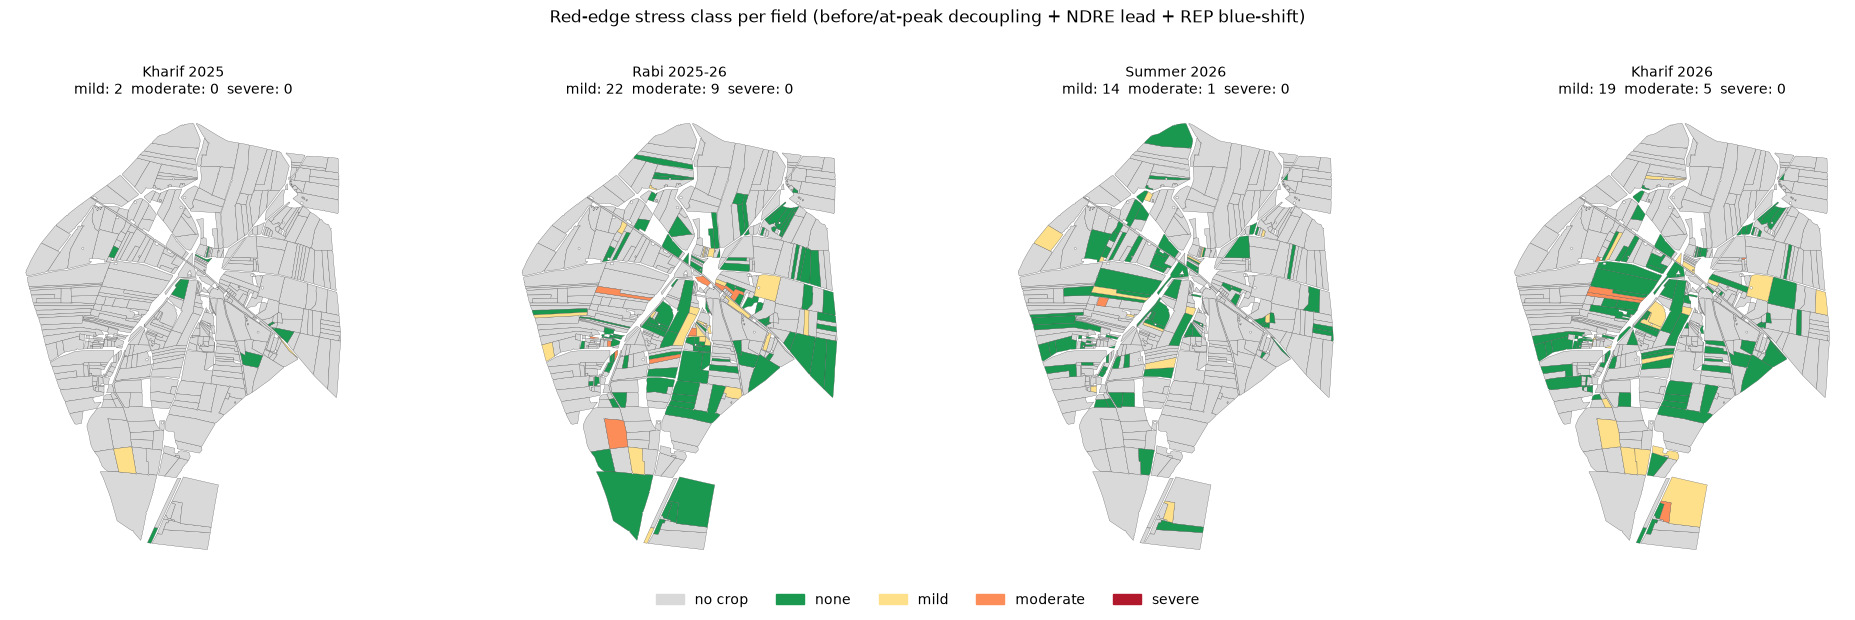

In [11]:
CLS = ["no crop", "none", "mild", "moderate", "severe"]
CCOL = ["#d9d9d9", "#1a9850", "#fee08b", "#fc8d59", "#b2182b"]
fig, axs = plt.subplots(1, len(SEASONS), figsize=(5 * len(SEASONS), 6.2))
for a, season in zip(axs, SEASONS):
    m = fields.merge(ph[ph.season == season][["field_id", "stress_class"]], on="field_id", how="left")
    m["stress_class"] = m.stress_class.fillna("no crop")
    for c, col in zip(CLS, CCOL):
        sub = m[m.stress_class == c]
        if len(sub):
            sub.plot(ax=a, color=col, edgecolor="0.3", lw=0.2)
    n = m.stress_class.value_counts()
    a.set_title(f"{season}\n" + "  ".join(f"{c}: {n.get(c, 0)}" for c in CLS[2:]), fontsize=10); a.set_axis_off()
from matplotlib.patches import Patch
fig.legend([Patch(color=c) for c in CCOL], CLS, loc="lower center", ncol=5, frameon=False)
fig.suptitle("Red-edge stress class per field (before/at-peak decoupling + NDRE lead + REP blue-shift)", y=0.98)
plt.tight_layout(rect=(0, 0.05, 1, 0.95)); plt.savefig(OUT / "03_stress_class_maps.png", dpi=150); plt.show()

## 11. Stress calendar: every field × time, decoupling z

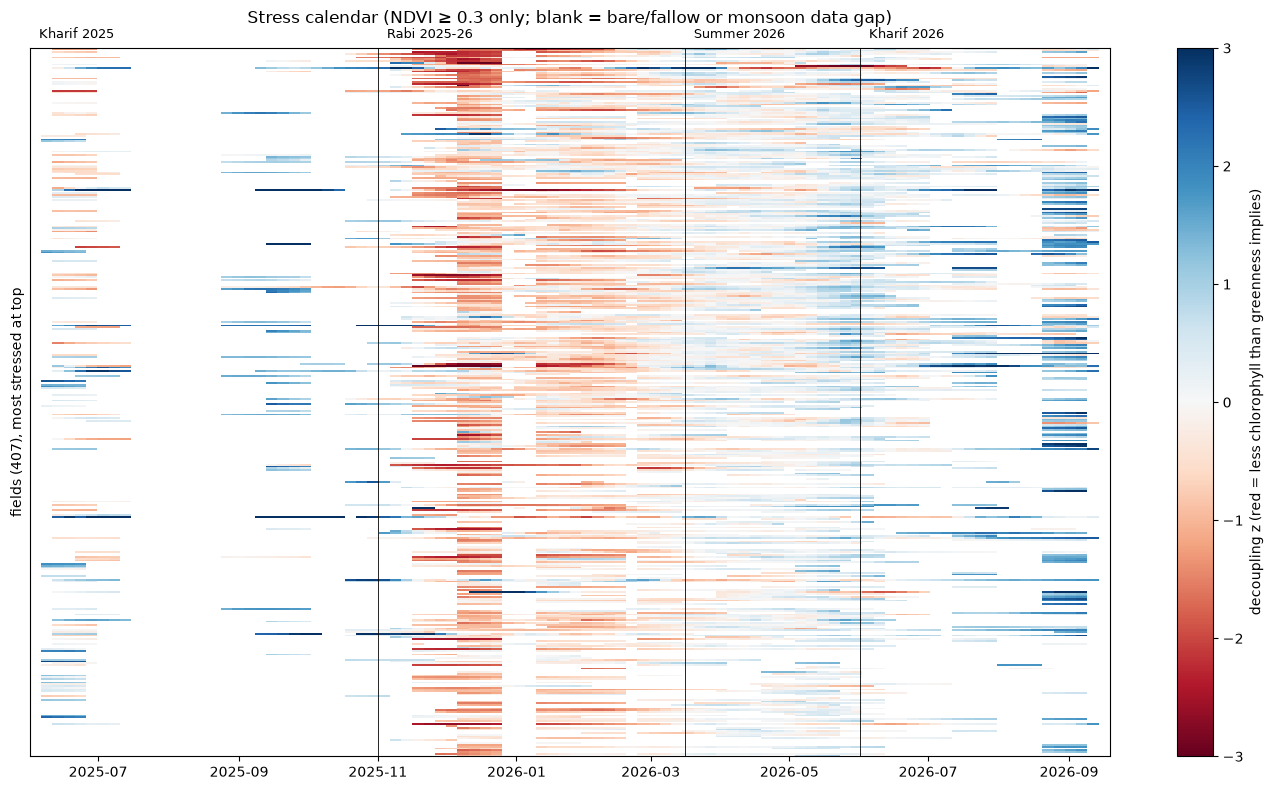

In [12]:
piv = fld_sm.pivot(index="field_id", columns="date", values="decouple_z")
vegmask = fld_sm.pivot(index="field_id", columns="date", values="ndvi") >= 0.3
piv = piv.where(vegmask)
order = ph[ph.cropped == True].groupby("field_id").stress_days_prepeak.sum().reindex(piv.index).fillna(-1).sort_values(ascending=False).index
piv = piv.loc[order]
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(piv.values, aspect="auto", cmap="RdBu", vmin=-3, vmax=3, interpolation="nearest",
               extent=(plt.matplotlib.dates.date2num(piv.columns[0]), plt.matplotlib.dates.date2num(piv.columns[-1]), len(piv), 0))
ax.xaxis_date(); ax.set_ylabel(f"fields ({len(piv)}), most stressed at top"); ax.set_yticks([])
for nm, (s0, s1) in SEASONS.items():
    ax.axvline(pd.Timestamp(s0), color="k", lw=0.6)
    ax.text(pd.Timestamp(s0) + pd.Timedelta(days=4), -4, nm, fontsize=9, va="bottom")
plt.colorbar(im, ax=ax, label="decoupling z (red = less chlorophyll than greenness implies)")
ax.set_title("Stress calendar (NDVI ≥ 0.3 only; blank = bare/fallow or monsoon data gap)", pad=18)
plt.tight_layout(); plt.savefig(OUT / "04_stress_calendar.png", dpi=150); plt.show()

## 12. The most stressed fields: NDVI and NDRE trajectories with stress windows

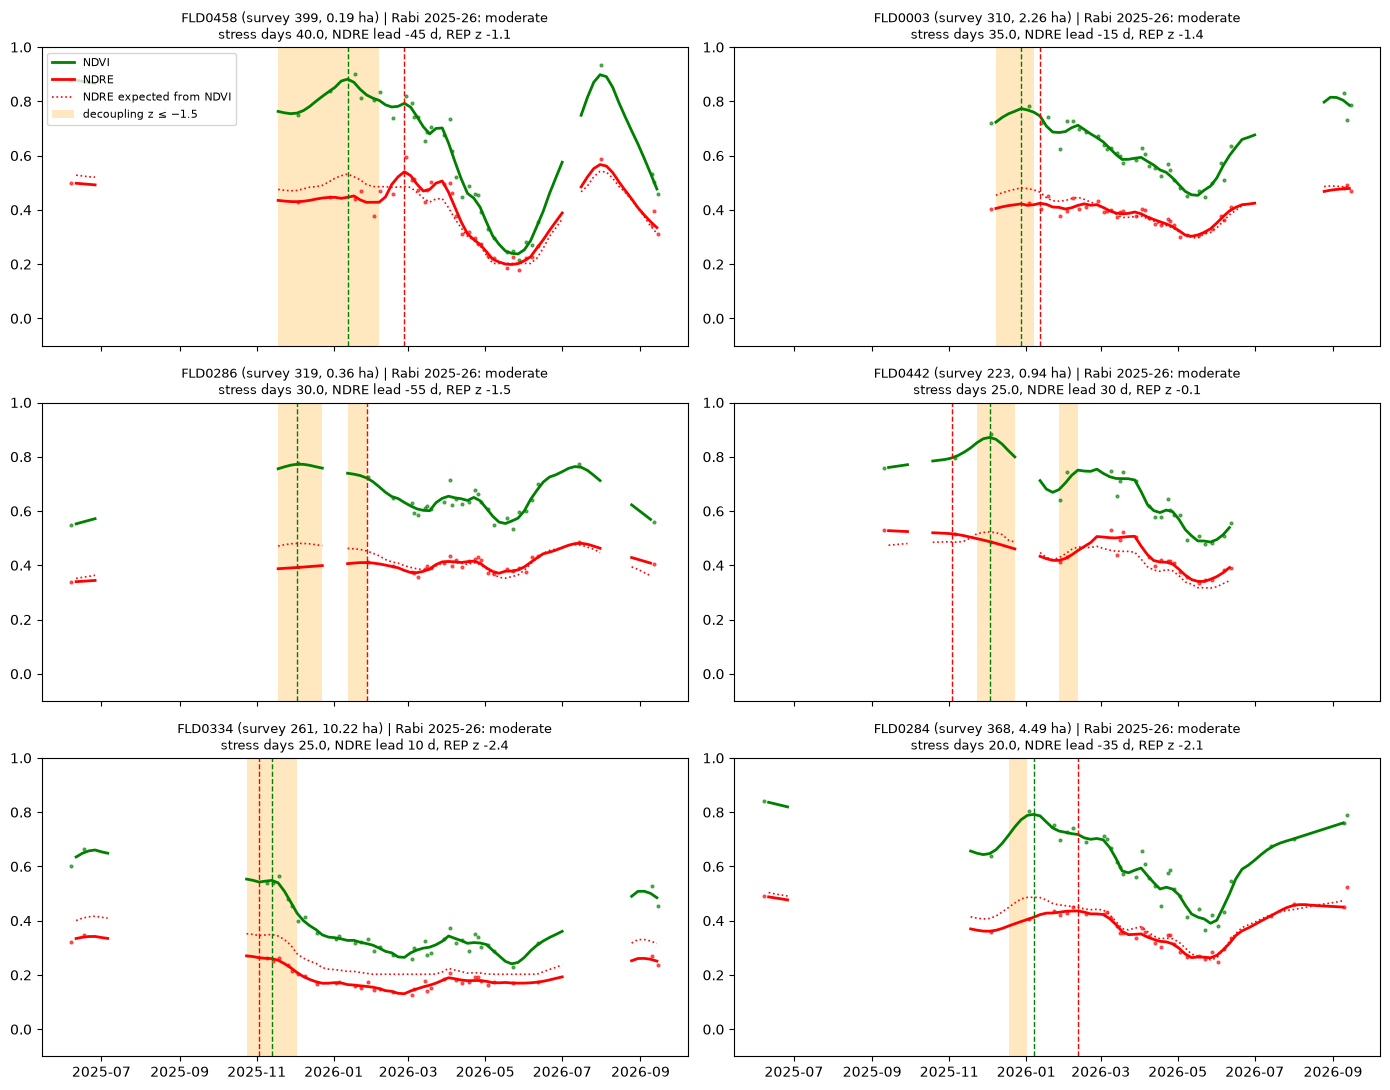

In [13]:
top = (ph[ph.cropped == True].sort_values(["stress_score", "stress_days_prepeak", "min_decouple_z_prepeak"], ascending=[False, False, True])
       .drop_duplicates("field_id").head(6))
fig, axs = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
for a, r in zip(axs.ravel(), top.itertuples()):
    g = fld_sm[fld_sm.field_id == r.field_id]; gr = fld_clean[fld_clean.field_id == r.field_id]
    a.plot(g.date, g.ndvi, "g-", lw=2, label="NDVI"); a.plot(gr.date, gr.ndvi, "g.", ms=4, alpha=0.6)
    a.plot(g.date, g.ndre, "r-", lw=2, label="NDRE"); a.plot(gr.date, gr.ndre, "r.", ms=4, alpha=0.6)
    a.plot(g.date, g.ndre_exp, "r:", lw=1.2, label="NDRE expected from NDVI")
    st = g.decouple_z <= -1.5
    a.fill_between(g.date, 0, 1, where=st, transform=a.get_xaxis_transform(), color="orange", alpha=0.25, lw=0, label="decoupling z ≤ −1.5")
    s0, s1 = SEASONS[r.season]
    a.axvline(r.pos_ndvi, color="g", ls="--", lw=1); a.axvline(r.pos_ndre, color="r", ls="--", lw=1)
    a.set_title(f"{r.field_id} (survey {r.survey_no}, {r.field_area_ha:.2f} ha) | {r.season}: {r.stress_class}\n"
                f"stress days {r.stress_days_prepeak}, NDRE lead {r.ndre_lead_days:.0f} d, REP z {r.s2rep_z:.1f}", fontsize=9)
    a.set_ylim(-0.1, 1)
axs[0, 0].legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.savefig(OUT / "05_top_stressed_fields.png", dpi=150); plt.show()

## 13. Where inside the field? Segment-level decoupling on the worst date

The same NDRE-for-given-NDVI expectation, applied to each SAM segment on the field's worst stress date.
It shows whether stress affects the whole field (e.g. water, nutrients) or only a patch (e.g. waterlogging, pests, a different crop inside the survey number).

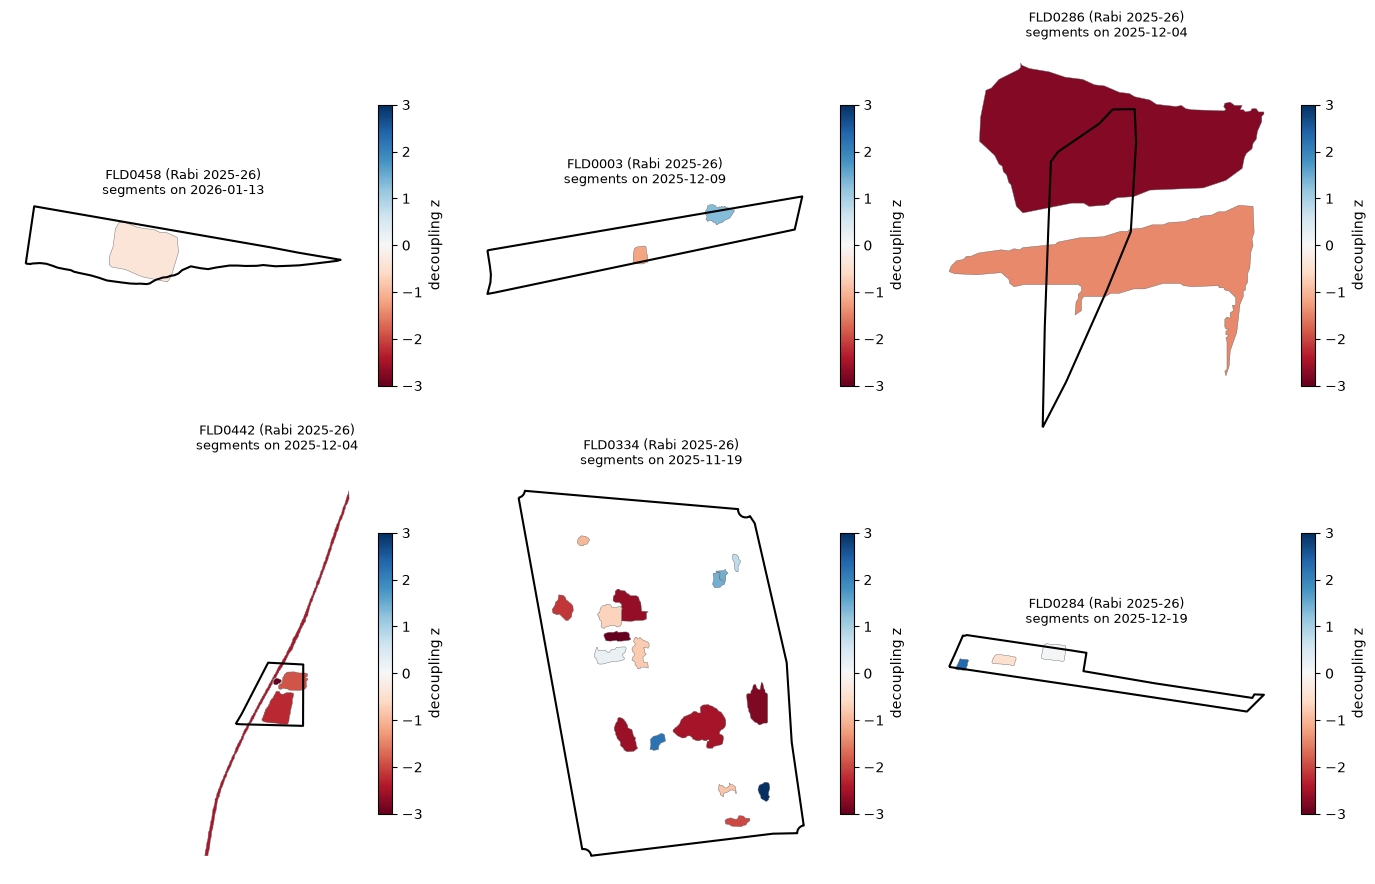

In [14]:
fig, axs = plt.subplots(2, 3, figsize=(14, 9))
for a, r in zip(axs.ravel(), top.itertuples()):
    f = fields[fields.field_id == r.field_id]
    sd = seg_raw[(seg_raw.field_id == r.field_id)]
    if pd.isna(r.worst_date) or sd.empty:
        a.set_axis_off(); continue
    d = sd.date.loc[(sd.date - r.worst_date).abs().idxmin()]
    sd = sd[sd.date == d].copy()
    sd["z"] = (sd.ndre - exp_ndre(sd.ndvi)) / spr_ndre(sd.ndvi) - base.get(r.field_id, 0)
    g = segs.merge(sd[["seg_id", "z", "ndvi"]], on="seg_id")
    f.boundary.plot(ax=a, color="k", lw=1.5)
    g.plot(ax=a, column="z", cmap="RdBu", vmin=-3, vmax=3, edgecolor="0.4", lw=0.3, legend=True,
           legend_kwds={"shrink": 0.7, "label": "decoupling z"})
    a.set_title(f"{r.field_id} ({r.season})\nsegments on {pd.Timestamp(d).date()}", fontsize=9); a.set_axis_off()
plt.tight_layout(); plt.savefig(OUT / "06_intrafield_segment_stress.png", dpi=150); plt.show()

## 14. Animation: decoupling-z map through the year, with the village timeline

In [15]:
from PIL import Image
import io
dz = fld_sm.pivot(index="date", columns="field_id", values="decouple_z").where(
     fld_sm.pivot(index="date", columns="field_id", values="ndvi") >= 0.3)
ndv = fld_sm.pivot(index="date", columns="field_id", values="ndvi")
frac = (dz <= -1.5).sum(1) / dz.notna().sum(1).replace(0, np.nan)
vmed = ndv.median(1); remed = fld_sm.groupby("date").ndre.median()
frames = []
cmap = plt.get_cmap("RdBu").copy(); norm = mcolors.Normalize(-3, 3)
for d in dz.index:
    fig = plt.figure(figsize=(10, 7.5)); gs = fig.add_gridspec(2, 2, height_ratios=[3.2, 1], width_ratios=[1, 1])
    ax1, ax2, ax3 = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, :])
    m = fields.assign(z=fields.field_id.map(dz.loc[d]), n=fields.field_id.map(ndv.loc[d]))
    m.plot(ax=ax1, column="n", cmap="RdYlGn", vmin=0, vmax=0.9, edgecolor="0.3", lw=0.15, missing_kwds={"color": "0.85"})
    m.plot(ax=ax2, column="z", cmap=cmap, norm=norm, edgecolor="0.3", lw=0.15, missing_kwds={"color": "0.85"})
    ax1.set_title("NDVI (canopy greenness)"); ax2.set_title("red-edge decoupling z (red = stress)")
    for a in (ax1, ax2): a.set_axis_off()
    ax3.plot(vmed.index, vmed, "g-", label="village median NDVI"); ax3.plot(remed.index, remed, "r-", label="village median NDRE")
    ax3b = ax3.twinx(); ax3b.fill_between(frac.index, 0, frac, color="orange", alpha=0.35, label="share of green fields in stress")
    ax3b.set_ylim(0, 1); ax3b.set_ylabel("stress share")
    ax3.axvline(d, color="k", lw=1.5); ax3.set_ylim(0, 0.9); ax3.legend(loc="upper left", fontsize=7); ax3b.legend(loc="upper right", fontsize=7)
    fig.suptitle(f"Loni: red-edge stress  |  {d:%d %b %Y}", fontsize=13)
    buf = io.BytesIO(); plt.savefig(buf, format="png", dpi=72); plt.close(fig)
    frames.append(Image.open(buf).convert("P", palette=Image.ADAPTIVE))
frames[0].save(OUT / "07_rededge_stress_animation.gif", save_all=True, append_images=frames[1:], duration=220, loop=0, optimize=True)
print(f"{len(frames)} frames -> {OUT/'07_rededge_stress_animation.gif'}")

/tmp/ipykernel_3398/808511317.py:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  frac = (dz <= -1.5).sum(1) / dz.notna().sum(1).replace(0, np.nan)
/tmp/ipykernel_3398/808511317.py:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  frac = (dz <= -1.5).sum(1) / dz.notna().sum(1).replace(0, np.nan)
/tmp/ipykernel_3398/808511317.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of median will be keyword-only.
  vmed = ndv.median(1); remed = fld_sm.groupby("date").ndre.median()


96 frames -> rededge_stress_outputs/07_rededge_stress_animation.gif


## 15. Reading the results / caveats

* **Decoupling after the peak is not stress.** Chlorophyll breaks down at maturity before the canopy thins, so NDRE falls before NDVI at the end of every healthy season. That is why only decoupling before or at the peak goes into `f_decouple`, and after-peak days are reported separately as `senescence_days`.
* **Crop type confounds single dates.** Different crops sit at different points on the NDRE–NDVI curve. The per-field baseline (`base_z`) removes a constant offset, but a field that changes crop between seasons can still show an artificial shift. Look at the season-level flags, not single dates.
* **Monsoon gaps.** Kharif has few clear scenes. Gaps longer than about 20 days from any real observation are left blank rather than interpolated, so Kharif stress days are a lower bound.
* **Resolution.** The red-edge bands are 20 m. Segments smaller than about 1,600 m² contain fewer than 4 independent red-edge pixels, so treat the segment map in §13 as indicative.
* **Stress type is not identified.** Water deficit, nitrogen deficiency, disease and waterlogging all lower chlorophyll. For water stress specifically, compare the flagged fields with the soil-moisture (SMI) series in this repo or with SWIR-based indices (NDMI from B8A/B11).